# GSB 5544 — PA 6.1: Writing Functions — INSTRUCTOR SOLUTION
*Textbook: [Chapter 6, Writing Functions](https://ds-ml-with-python.github.io/Course-Textbook/05-function_writing.html)
— scope, dynamic lookup, unit tests, and input validation*

**How to use this notebook.** Each question is answered in the same five beats: **Approach** (the idea, in a
sentence or two) → **code** (complete and executed) → **What the code does** (piece by piece) → **Expected
output** → **Common mistakes** (what students actually do, and the symptom you will see on their screen).

**The one idea to keep returning to:** *a function is a small, sealed environment.* Arguments go in, one value
comes back through `return`, and nothing inside changes the objects outside (Questions 0 and 4). Everything
between the input and the `return` — including checking the input (Questions 1–3) — is your job as the author.

**Before class: a slip in the printed `add_or_subtract` (Questions 3–4).** Its final `return res` is indented
*inside* the `else` block, after `exit(...)`, so it can never run: as printed, `"add"` and `"subtract"` calls
return `None`. The answers below give the **intended** behaviour (the `return` one level out) and show what the
printed version does, so you can either fix the handout or use it as a live "where does `return` sit?" moment.

In [1]:
#!pip install palmerpenguins

In [2]:
import numpy as np
import pandas as pd
from sys import exit
from palmerpenguins import load_penguins
from plotnine import ggplot, aes, geom_point, geom_bar

0\. Complete the [**check-in** from Section 6.3.2](https://ds-ml-with-python.github.io/Course-Textbook/05-function_writing.html#nested-environments-and-scope): Write a custom function that does the following:

Limit the penguins dataset to a user-chosen species and/or island.
Makes a scatterplot of the penguin bill length and depth.
Try writing a version of this function using dynamic lookup, and a version where everything the function needs is passed in directly

### Solution 0 — the Section 6.3.2 check-in: one plotting function, two ways

**Approach.** "Species and/or island" means each filter is **optional**: give both parameters the default
`None`, and filter only on the ones the user supplied. Then write the function twice — once reaching out to
the global `penguins` (**dynamic lookup**), once receiving the data as an argument (**everything passed in**) —
and compare how each behaves when the global data changes.

In [3]:
from plotnine import labs

penguins = load_penguins()

# Version 1 — DYNAMIC LOOKUP: the function is never given the data; it finds `penguins` in the global environment
def plot_bills_dynamic(species = None, island = None):
  """
  Scatterplot of bill length vs. bill depth for a chosen species and/or island.

  Parameters
  ----------
  species : str, optional
    "Adelie", "Chinstrap", or "Gentoo". None (the default) keeps every species.
  island : str, optional
    "Biscoe", "Dream", or "Torgersen". None (the default) keeps every island.

  Returns
  -------
  ggplot
    The scatterplot.
  """
  subset = penguins                                      # <- looked up in the GLOBAL environment
  if species is not None:
    subset = subset[subset["species"] == species]
  if island is not None:
    subset = subset[subset["island"] == island]
  subset = subset.dropna(subset = ["bill_length_mm", "bill_depth_mm"])

  plot = (ggplot(subset, aes(x = "bill_length_mm", y = "bill_depth_mm"))
          + geom_point()
          + labs(title = f"species = {species}, island = {island}  (n = {len(subset)})",
                 x = "Bill length (mm)", y = "Bill depth (mm)"))
  return plot

Unit tests — a species only, an island only, and both:

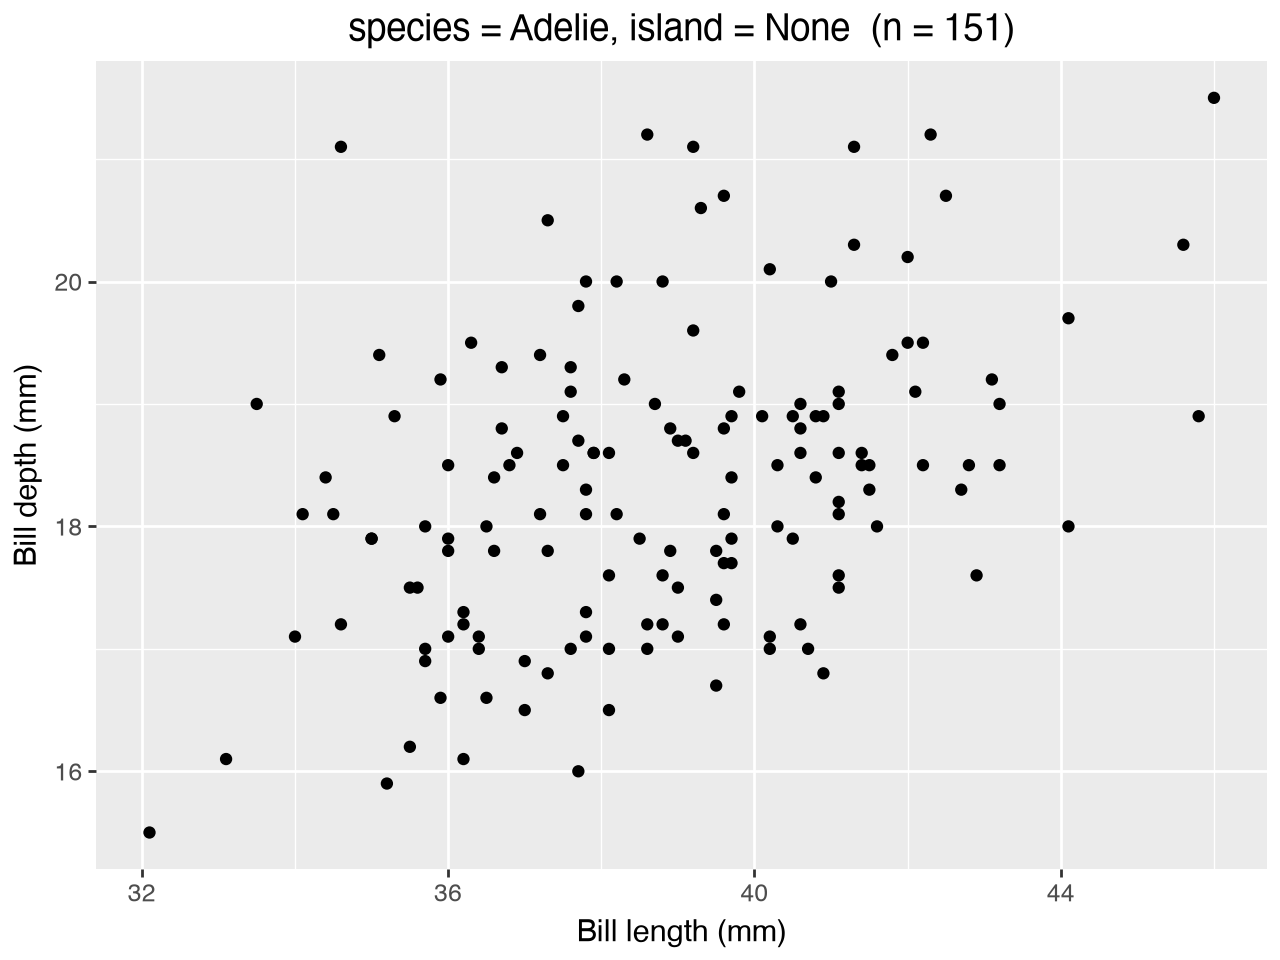

In [4]:
plot_bills_dynamic(species = "Adelie")

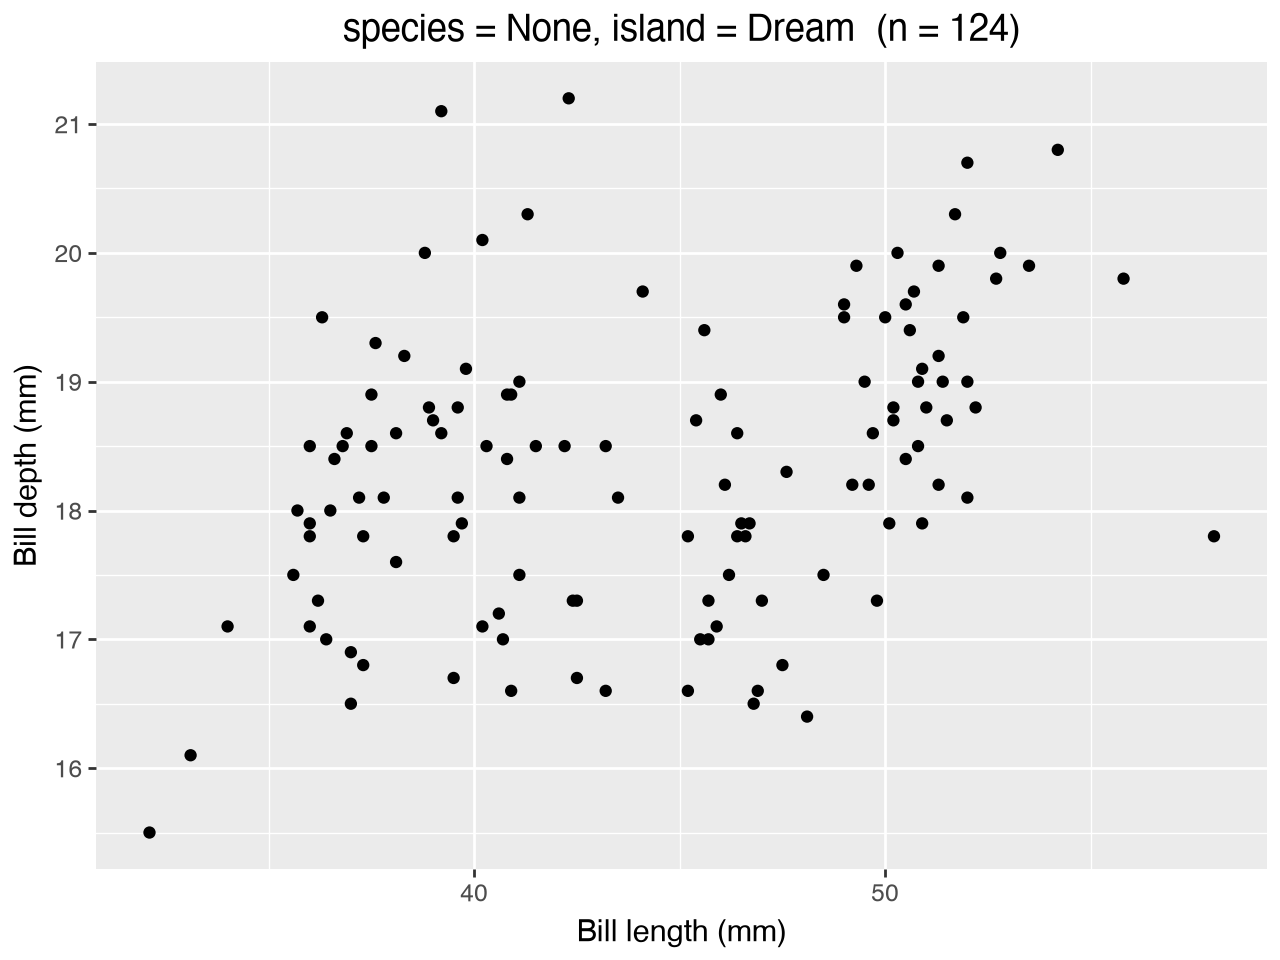

In [5]:
plot_bills_dynamic(island = "Dream")

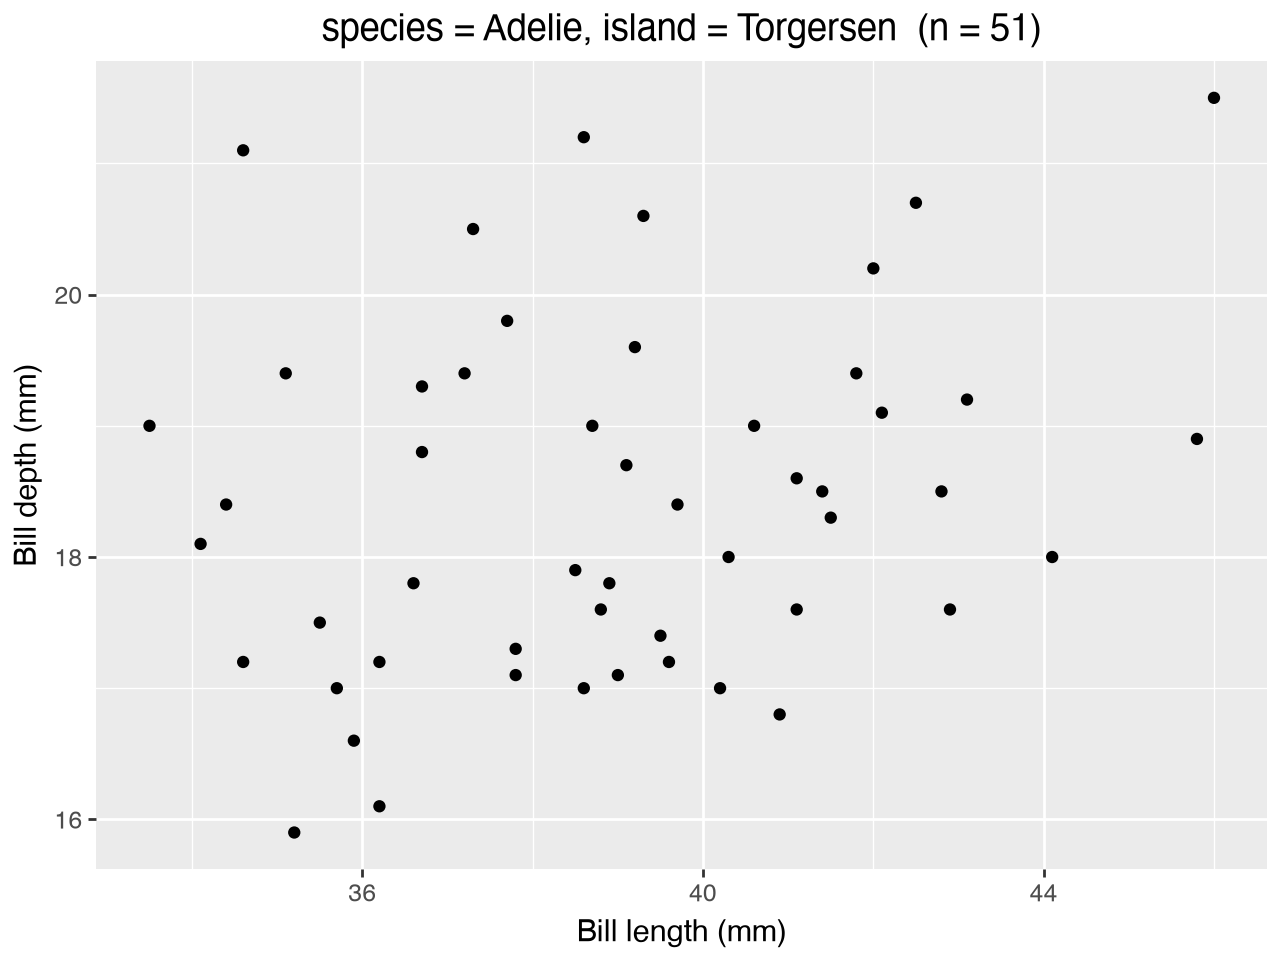

In [6]:
plot_bills_dynamic(species = "Adelie", island = "Torgersen")

In [7]:
# Version 2 — EVERYTHING PASSED IN: the data is a parameter, and the inputs are checked before use
def plot_bills(data, species = None, island = None):
  """
  Scatterplot of bill length vs. bill depth for a chosen species and/or island.

  Parameters
  ----------
  data : pandas DataFrame
    Penguin data with columns species, island, bill_length_mm, bill_depth_mm.
  species : str, optional
    A species present in `data`. None (the default) keeps every species.
  island : str, optional
    An island present in `data`. None (the default) keeps every island.

  Returns
  -------
  ggplot
    The scatterplot.
  """
  if not isinstance(data, pd.DataFrame):
    exit("Please provide the penguin data as a pandas DataFrame.")
  if species is not None and species not in data["species"].unique():
    exit(f"species must be one of {sorted(data['species'].unique())}.")
  if island is not None and island not in data["island"].unique():
    exit(f"island must be one of {sorted(data['island'].unique())}.")

  subset = data                                          # <- only what was handed in
  if species is not None:
    subset = subset[subset["species"] == species]
  if island is not None:
    subset = subset[subset["island"] == island]
  subset = subset.dropna(subset = ["bill_length_mm", "bill_depth_mm"])

  plot = (ggplot(subset, aes(x = "bill_length_mm", y = "bill_depth_mm"))
          + geom_point()
          + labs(title = f"species = {species}, island = {island}  (n = {len(subset)})",
                 x = "Bill length (mm)", y = "Bill depth (mm)"))
  return plot

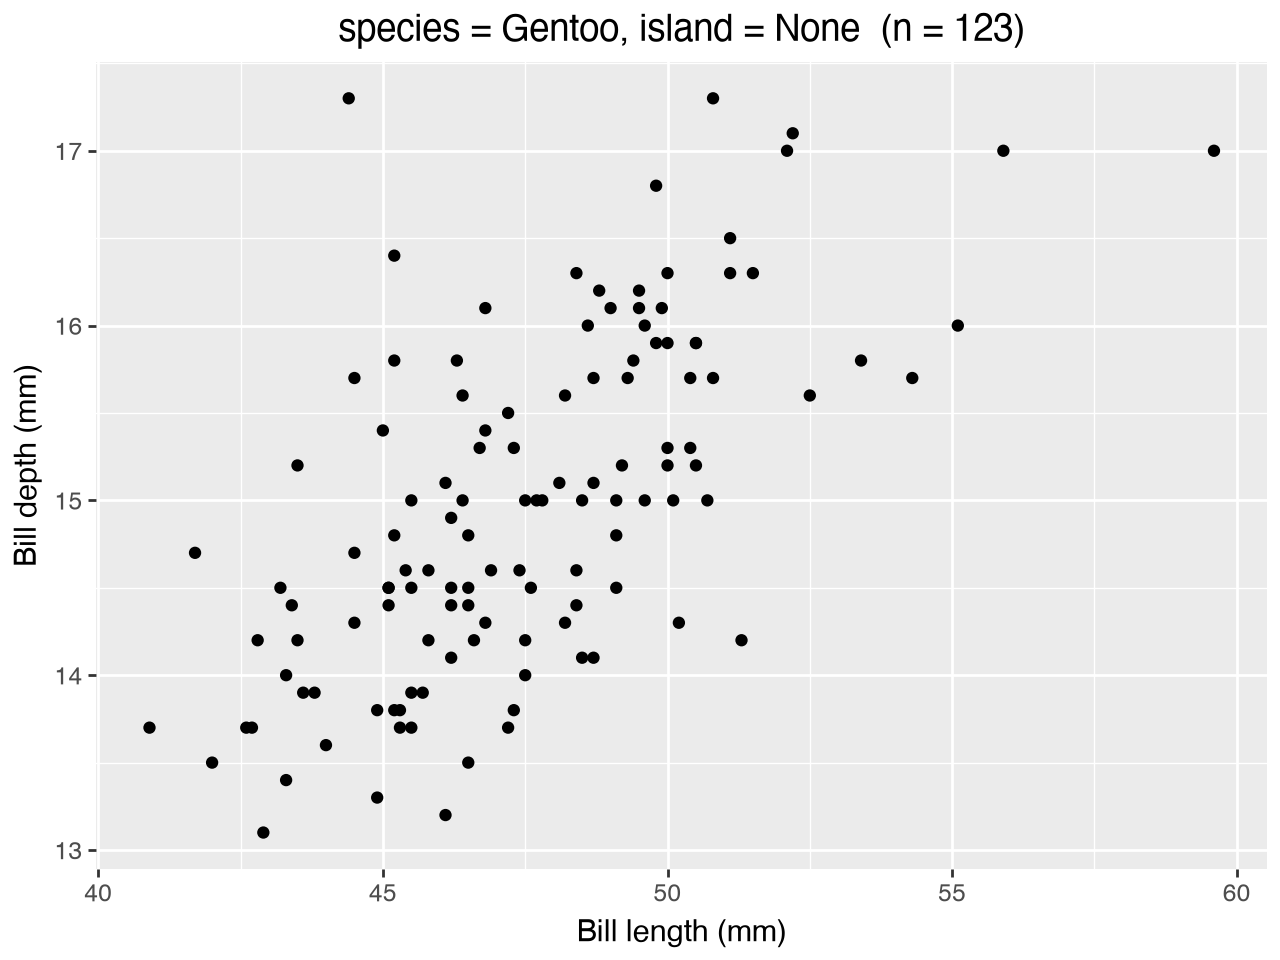

In [8]:
plot_bills(penguins, species = "Gentoo")

In [9]:
plot_bills(penguins, species = "adelie")          # lower-case typo -> stopped with a helpful message

SystemExit: species must be one of ['Adelie', 'Chinstrap', 'Gentoo'].

/opt/anaconda3/lib/python3.14/site-packages/IPython/core/interactiveshell.py:3756: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.


In [10]:
# A valid combination that simply has no penguins: Gentoo live only on Biscoe
plot_bills(penguins, species = "Gentoo", island = "Dream").data.shape

(0, 8)

**Why "pass everything in" is the safer default.** Suppose, later in the analysis, someone narrows the global
data frame. The dynamic-lookup version silently follows it; the passed-in version only ever uses what it is given:

In [11]:
penguins = penguins[penguins["island"] == "Biscoe"]            # the global data changes ...

print("dynamic lookup, Adelie:", plot_bills_dynamic(species = "Adelie").data.shape[0], "penguins")
print("passed in,      Adelie:", plot_bills(load_penguins(), species = "Adelie").data.shape[0], "penguins")

penguins = load_penguins()                                     # restore the full data

dynamic lookup, Adelie: 44 penguins
passed in,      Adelie: 151 penguins


**What the code does.**
- **`species = None, island = None`** — default arguments make both filters optional, which is what "and/or"
  asks for. `if species is not None:` filters only when the user supplied a species.
- **`subset = subset[subset["species"] == species]`** — the Week 2 boolean filter, applied one condition at a
  time, so any combination of the two works without four separate branches.
- **`dropna(...)`** — two penguins have no bill measurements; dropping them avoids plotnine's
  *"Removed 2 rows containing missing values"* warning and makes the `n` in the title honest.
- **`return plot`** — the function hands the plot back. The notebook displays it because it is the cell's last
  value, and the caller can still add to it (`plot_bills(penguins) + labs(...)`), which a `print` would not allow.
- **Version 1's `subset = penguins`** is the dynamic lookup: `penguins` is not a parameter, so Python looks in
  the function's local environment, does not find it, and falls back to the global one (textbook §6.3.2).
- **Version 2's checks** follow textbook §6.4.2: `isinstance` for a Python type, `in data[...].unique()` for a
  valid value, and `exit(...)` with a message that tells the user how to fix the call.
- `.data.shape` reads the data frame stored inside a plotnine plot — a quick way to unit-test the filter
  without looking at a picture.

**Expected output.** Adelie: 151 penguins (152 minus 1 with missing bills) spread over all three islands.
Dream: 124 (56 Adelie + 68 Chinstrap; none missing). Adelie on Torgersen: 51. Gentoo: 123. The `"adelie"`
typo stops with `SystemExit: species must be one of ['Adelie', 'Chinstrap', 'Gentoo'].` Gentoo on Dream is a
legitimate empty result, `(0, 8)`. After the global data is narrowed to Biscoe, the dynamic version reports
**44** Adelie while the passed-in version still reports **151** — the same call, a different answer, and no
error to warn you.

**Common mistakes.**
- **Required arguments instead of defaults** (`def f(species, island)`) — then "species only" is impossible
  without passing a dummy island.
- **`if species:` / `== None`** instead of `is not None` — works here, but `is not None` is the idiom and
  says exactly what is meant.
- **Combining conditions with `and`**: `penguins[(penguins.species == s) and (penguins.island == i)]` →
  `ValueError: The truth value of a Series is ambiguous`. Element-wise conditions need `&` and parentheses.
- **Case-sensitive values**: `"adelie"` matches nothing, and without a check the result is a silent, empty plot.
- **Calling the "passed-in" version with a filtered copy by accident** — the point of Version 2 is that the
  caller decides what data goes in, so the call site should make that visible.
- **`print(plot)` inside the function** instead of `return plot` — the plot appears, but the function
  returns `None`, so the caller cannot modify or save it.

1. Fill in the necessary code to write a function called `times_seven()`. The function should take a single argument (`x`) and multiply the input by 7.
  + This function should check that the argument is numeric.
  + This function should also excitedly announce (print) *“I love sevens!”* if the argument to the function is a 7.

### Solution 1 — `times_seven()`

**Approach.** Three steps, in order: **check** the input (stop with a message if it is not a number),
**announce** if it is a 7, **return** the input times 7. The check comes first so nothing is computed on bad input.

In [12]:
def times_seven(x):

  if not isinstance(x, (int, float)):
    exit("Please provide a single number (an int or a float) for x.")

  if x == 7:
    print("I love sevens!")

  return x * 7

**What the code does.**
- **`isinstance(x, (int, float))`** is `True` when `x` is an `int` *or* a `float` — a tuple of types means
  "any of these". `not` reverses it, so the `exit` runs only for non-numbers (textbook §6.4.2).
- **`exit("...")`** (imported from `sys` at the top of the notebook) stops the function and shows the message.
  Say what was expected, so the user knows how to fix the call.
- **`print("I love sevens!")`** is a message *for the person* — it does not change what the function returns.
- **`return x * 7`** hands the result back to the caller.

**Common mistakes.**
- **`return print(x * 7)`** or printing instead of returning → the number shows on screen but the function
  returns `None`, so `times_seven(2) + 1` fails.
- **`type(x) == int`** → rejects floats (`times_seven(1.5)` exits). Use `isinstance` with both types.
- **`if x = 7:`** → `SyntaxError`; comparison is `==`.
- **Checking with `x.isnumeric()`** — that is a *string* method; on a number it raises `AttributeError`.
- **Putting the `return` before the `print`** → the announcement never happens (code after `return` does not run).

2. Write and run some *unit tests* for your `times_seven` function.  What happens if the input to the function is `[1, 3, 5, 7]`?

### Solution 2 — unit tests, and a list as input

**Approach.** Test the ordinary cases (a 7, other integers, a float, zero, a negative), then the unexpected
ones (a string, a list). A test is only useful if you know the right answer *before* running it, so the
`assert` statements write the expected value down.

In [13]:
times_seven(7)                       # the special case: prints AND returns

I love sevens!


49

In [14]:
times_seven(2), times_seven(-1.5), times_seven(0)

(14, -10.5, 0)

In [15]:
assert times_seven(2) == 14
assert times_seven(-1.5) == -10.5
assert times_seven(0) == 0
assert times_seven(7) == 49          # also prints the announcement
print("all ordinary-input tests passed")

I love sevens!
all ordinary-input tests passed


Unexpected input — each call should stop with our message rather than return something strange:

In [16]:
times_seven("7")

SystemExit: Please provide a single number (an int or a float) for x.

/opt/anaconda3/lib/python3.14/site-packages/IPython/core/interactiveshell.py:3756: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.


In [17]:
times_seven([1, 3, 5, 7])

SystemExit: Please provide a single number (an int or a float) for x.

**Why the check matters for the list.** Without it, Python would happily run `[1, 3, 5, 7] * 7` — but `*` on
a list means *repeat the list*, and a list is never `== 7`, so there is no announcement either:

In [18]:
repeated = [1, 3, 5, 7] * 7
print(len(repeated), repeated[:8], "...")
print([1, 3, 5, 7] == 7)

28 [1, 3, 5, 7, 1, 3, 5, 7] ...
False


**If the user really wants each number times 7**, apply the function to each element — this is `map()` from
Topic 6.1:

In [19]:
list(map(times_seven, [1, 3, 5, 7]))

I love sevens!


[7, 21, 35, 49]

A test that *expects* the error, so a whole test cell can run without stopping:

In [20]:
try:
  times_seven([1, 3, 5, 7])
  print("TEST FAILED: a list was accepted")
except SystemExit as err:
  print("stopped as expected:", err)

stopped as expected: Please provide a single number (an int or a float) for x.


**Two edge cases worth showing.** A Python quirk: `True` is an `int` (it equals 1), so it passes the check. And a
number that came out of numpy — for example a value pulled from a pandas column — is *not* a Python `int`:

In [21]:
times_seven(True)

7

In [22]:
times_seven(np.int64(7))             # a numpy integer is not an instance of int

SystemExit: Please provide a single number (an int or a float) for x.

In [23]:
from numbers import Number

def times_seven_v2(x):

  if isinstance(x, bool) or not isinstance(x, Number):
    exit("Please provide a single number for x.")

  if x == 7:
    print("I love sevens!")

  return x * 7

times_seven_v2(np.int64(7)), times_seven_v2(2.5)

I love sevens!


(np.int64(49), 17.5)

**What the code does.**
- `assert condition` does nothing when the condition is `True` and raises `AssertionError` when it is
  `False` — a test that writes down the expected answer.
- `try:` / `except SystemExit as err:` catches the stop that `exit` raises, so we can check that it *did* stop
  and read its message (`err`).
- `list(map(times_seven, [1, 3, 5, 7]))` calls `times_seven` once per element: four numbers in, four out.
- `numbers.Number` is the "any kind of number" type: it includes numpy's number types; excluding `bool`
  explicitly closes the `True` loophole.

**Expected output.** `times_seven(7)` prints *I love sevens!* and returns 49; the others give `(14, -10.5, 0)`;
the asserts pass. `"7"` and `[1, 3, 5, 7]` both stop with `SystemExit: Please provide a single number (an int or
a float) for x.` Unchecked, the list would become a 28-element list, with no announcement. Mapped over the list:
*I love sevens!* printed **once** (only for the 7) and `[7, 21, 35, 49]`. `times_seven(True)` returns 7;
`np.int64(7)` is rejected by the original check and accepted by `times_seven_v2`, which returns
`(np.int64(49), 17.5)` and prints the announcement.

**Common mistakes.**
- **"Testing" by eye** — running `times_seven(2)` and not deciding in advance that the answer should be 14.
- **Only testing the happy path.** The list case is the one that shows *why* the validation exists.
- **Putting several error-raising calls in one cell** — execution stops at the first, and the others never run.
  One call per cell, or `try`/`except` as above.
- **Answering "it multiplies each number by 7"** — that is true for a numpy array (`np.array([1, 3, 5, 7]) * 7`),
  not for a Python list.

3. Consider the following function:

In [24]:
def add_or_subtract(first_num, second_num = 2, type = "add"):

  if (type == "add"):
    res = first_num + second_num
  elif (type == "subtract"):
    res = first_num - second_num
  else:
    exit("Please choose `add` or `subtract` as the type.")

    return res

**Without running the code**, predict if the following will produce:

a. 1

b. -1

c. 30

d. An error defined by the function `add_or_subtract()`

e. An error defined in a different function, which is called inside the `add_or_subtract()` function

### Solution 3 — predictions

**Approach.** Follow each call through the function with its defaults filled in: `second_num = 2` and
`type = "add"` unless the call says otherwise. Then ask: which branch runs, and *who* raises any error — the
function's own `exit`, or Python itself?

| Call | Filled in | Answer |
|---|---|---|
| `add_or_subtract(5, 6, type = "subtract")` | 5 − 6 | **b. −1** |
| `add_or_subtract("orange")` | `"orange" + 2` | **e.** an error from Python's `+`, raised inside our function |
| `add_or_subtract(5, 6, type = "multiply")` | no branch matches → `else` | **d.** the function's own `exit` message |

Options a (1) and c (30) are the distractors for "subtracted in the wrong order" and "multiplied anyway".

Each call runs in its own cell, because the second and third stop with an error. First, **with the function
exactly as printed**:

In [25]:
print(add_or_subtract(5, 6, type = "subtract"))     # as printed: `return res` sits inside the else block

None


In [26]:
add_or_subtract("orange")

TypeError: can only concatenate str (not "int") to str

In [27]:
add_or_subtract(5, 6, type = "multiply")

SystemExit: Please choose `add` or `subtract` as the type.

The first call shows **`None`**, not −1: the subtraction happens, but the only `return` is inside the `else`
block, after `exit(...)`, where it can never be reached. Moving `return res` out one level gives the intended
function. We keep the printed one under another name for Question 4:

In [28]:
add_or_subtract_as_printed = add_or_subtract       # keep the printed version for comparison

def add_or_subtract(first_num, second_num = 2, type = "add"):

  if (type == "add"):
    res = first_num + second_num
  elif (type == "subtract"):
    res = first_num - second_num
  else:
    exit("Please choose `add` or `subtract` as the type.")

  return res                                     # one level out: runs after "add" or "subtract"

add_or_subtract(5, 6, type = "subtract")

-1

**What the code does.**
- **Call 1**: `type = "subtract"` → `res = 5 - 6 = -1` → returned (once `return` is in the right place).
- **Call 2**: only `first_num` is given, so `second_num = 2` and `type = "add"`. The function runs
  `"orange" + 2`, and Python's `+` refuses: `TypeError: can only concatenate str (not "int") to str`. The
  message is Python's, not ours — the error is defined in a different function (the `+` operation) that is
  called *inside* `add_or_subtract`. **Answer e.**
- **Call 3**: `"multiply"` matches neither branch → `else` → `exit(...)` → `SystemExit` with the function's own
  message. **Answer d.**

**Expected output.** As printed: `None`, a `TypeError`, and `SystemExit: Please choose `add` or `subtract` as the
type.` With the corrected function, call 1 returns **−1**; calls 2 and 3 are unchanged.

**Common mistakes.**
- **Predicting d for "orange"** — the function never checks its inputs' types, so its own `exit` is not what
  stops it. (A validation line like Question 1's would turn this into a d.)
- **Predicting 1** — subtracting in the wrong order: `first_num - second_num` is 5 − 6.
- **Running all three calls in one cell** (as the handout lays them out) → only the `TypeError` appears.
- **Not noticing the indentation** — in Python, indentation *is* the structure. This is also why Topic 6.1 treats
  "forgot `return`" as the most common silent bug: no error, just `None`.
- A style note worth making: naming a parameter **`type`** masks the built-in `type()` inside the function
  (name masking, textbook §6.3.1). `operation = "add"` would be clearer.

4. Consider the following code:

In [29]:
first_num  = 5
second_num = 3

result = 8

result = add_or_subtract(first_num, second_num = 4)

result_2 = add_or_subtract(first_num)


In your Global Environment, what is the value of...

a. `first_num`

b. `second_num`

c. `result`

d. `result_2`

### Solution 4 — what is in the global environment?

**Approach.** Only assignments *in the global environment* change global objects. Inside a call,
`second_num = 4` sets the function's **parameter** in its own local environment; it does not touch the global
`second_num`. So: track each `=` at the top level, and evaluate each call with its defaults.

In [30]:
print("first_num  =", first_num)
print("second_num =", second_num)
print("result     =", result)
print("result_2   =", result_2)

first_num  = 5
second_num = 3
result     = 9
result_2   = 7


In [31]:
# The same two calls with the function exactly as printed in the handout
print(add_or_subtract_as_printed(first_num, second_num = 4), add_or_subtract_as_printed(first_num))

None None


**What the code does.** The Question 4 cell above ran with the corrected `add_or_subtract` from Solution 3.

| Object | Value | Why |
|---|---|---|
| **a. `first_num`** | **5** | assigned once at the top level; passing it into a function does not change it |
| **b. `second_num`** | **3** | `second_num = 4` inside the call is the function's *parameter*, not the global object — "what happens in a function stays in the function" |
| **c. `result`** | **9** | first 8, then **overwritten** by `add_or_subtract(5, second_num = 4)` = 5 + 4 (default `type = "add"`) |
| **d. `result_2`** | **7** | `add_or_subtract(5)` uses both defaults: 5 + 2 |

**Expected output.** 5, 3, 9, 7. With the function **as printed**, both calls return `None`, so `result` and
`result_2` would be `None` — and note that `result` would *still* be overwritten (8 → `None`), because the
assignment happens regardless of what the function returns.

**Common mistakes.**
- **`second_num = 4`** — believing the keyword argument reassigns the global variable. It names which
  parameter receives 4, nothing more.
- **`result = 8`** — forgetting that the later `result = ...` replaces it.
- **`result_2` is an error** — overlooking the defaults; `second_num` has one (`2`), so one argument is enough.
- **`result_2 = 8`** — assuming the call reuses the `second_num = 4` from the previous call. Every call starts a
  fresh local environment (textbook §6.3.2).